## Данные

Используются изображения:

    /content/train_images
    /content/test_images

Разметка загружается из файла:

    /content/drive/MyDrive/YAN/train_solution.csv

Train/validation split:

    test_size = 0.2
    stratify = labels
    random_state = 42

### 1. ConvNeXt-Tiny-подобная модель

Кастомная сверточная модель с ConvNeXt-блоками.

Схема:

    Input [B, 3, 224, 224]
            |
            v
    Conv Stem
    Conv2d kernel=4 stride=4
            |
            v
    Stage 1: ConvNeXt Block x 3, dim=96
            |
            v
    Stage 2: ConvNeXt Block x 3, dim=192
            |
            v
    Stage 3: ConvNeXt Block x 9, dim=384
            |
            v
    Stage 4: ConvNeXt Block x 3, dim=768
            |
            v
    Global Average Pooling
            |
            v
    LayerNorm
            |
            v
    Linear 768 -> 256
    GELU
    Dropout
    Linear 256 -> 1
            |
            v
    Output logit

---

In [ ]:
import glob
import os
import random
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from collections import OrderedDict
from typing import Optional, Sequence
import math
import albumentations as A
from albumentations.pytorch import ToTensorV2
from IPython.display import clear_output
import torch.nn.functional as F
import seaborn as sns

In [ ]:
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything()

In [ ]:
import warnings

warnings.filterwarnings('ignore')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
from PIL import Image
from torch.utils.data import Dataset

class TrainDataset(Dataset):
    def __init__(self, df, root_dir, transform=None):
        self.df = df
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_id = self.df.iloc[idx]["id"]
        label = self.df.iloc[idx]["label"]

        img_path = os.path.join(self.root_dir, f"{img_id}.jpg")
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = np.array(image)
            image = self.transform(image=image)["image"]

        return image, label

In [ ]:
class TestDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.files = os.listdir(root_dir)
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        file_name = self.files[idx]
        path = os.path.join(self.root_dir, file_name)

        image = Image.open(path).convert("RGB")

        if self.transform:
            image = np.array(image)
            image = self.transform(image=image)["image"]

        return image, file_name

In [ ]:
!pip install -U albumentations==1.4.1

# Обработка данных

In [ ]:
train_transforms_convnext = A.Compose([
    A.RandomResizedCrop(224, 224, scale=(0.85, 1.0), p=1.0),
    A.HorizontalFlip(p=0.5),

    A.ShiftScaleRotate(
        shift_limit=0.03,
        scale_limit=0.08,
        rotate_limit=5,
        p=0.3
    ),

    A.OneOf([
        A.MedianBlur(blur_limit=3, p=1.0),
        A.ImageCompression(quality_lower=70, quality_upper=100, p=1.0),
    ], p=0.3),

    A.RandomBrightnessContrast(p=0.3),
    A.HueSaturationValue(p=0.2),

    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

val_transforms_convnext = A.Compose([
    A.Resize(224, 224, p=1.0),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

In [ ]:
train_transforms_convnext = A.Compose([
    A.RandomResizedCrop(224, 224, scale=(0.85, 1.0), p=1.0),
    A.HorizontalFlip(p=0.5),

    A.ShiftScaleRotate(
        shift_limit=0.03,
        scale_limit=0.08,
        rotate_limit=5,
        p=0.3
    ),

    A.OneOf([
        A.MedianBlur(blur_limit=3, p=1.0),
        A.ImageCompression(quality_lower=70, quality_upper=100, p=1.0),
    ], p=0.3),

    A.RandomBrightnessContrast(p=0.3),
    A.HueSaturationValue(p=0.2),

    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

val_transforms_convnext = A.Compose([
    A.Resize(224, 224, p=1.0),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

In [ ]:
labels_for_train = pd.read_csv("/content/drive/MyDrive/YAN/train_solution.csv", header=None)
labels_for_train.columns = ["id", "label"]
train_df, val_df = train_test_split(
    labels_for_train,
    test_size=0.2,
    stratify=labels_for_train["label"],
    random_state=42
)

In [ ]:
!unzip -q /content/drive/MyDrive/YAN/train_images.zip -d /content/

In [ ]:
print(os.listdir("/content"))

['.config', 'train_images', 'drive', 'sample_data']


In [ ]:
print(len(os.listdir("/content/train_images")))

50000


In [ ]:
!unzip -q /content/drive/MyDrive/YAN/train_images.zip -d /content/

In [ ]:
train_dataset = TrainDataset(train_df, "/content/train_images", transform=train_transforms_convnext)
val_dataset   = TrainDataset(val_df,   "/content/train_images", transform=val_transforms_convnext)
test_dataset  = TestDataset("/content/test_images", transform=val_transforms_convnext)


train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4, pin_memory=True, persistent_workers=True, prefetch_factor=2)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4, pin_memory=True, persistent_workers=True, prefetch_factor=2)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4, pin_memory=True, persistent_workers=True, prefetch_factor=2)

# Модель ConvNeXt-Tiny

In [ ]:
def drop_path(x, drop_prob: float = 0., training: bool = False):
    if drop_prob == 0. or not training:
        return x
    keep_prob = 1 - drop_prob
    shape = (x.shape[0],) + (1,) * (x.ndim - 1)
    random_tensor = keep_prob + torch.rand(shape, dtype=x.dtype, device=x.device)
    random_tensor.floor_()
    output = x.div(keep_prob) * random_tensor
    return output

class DropPath(nn.Module):
    def __init__(self, drop_prob=None):
        super(DropPath, self).__init__()
        self.drop_prob = drop_prob
    def forward(self, x):
        return drop_path(x, self.drop_prob, self.training)

class LayerNorm(nn.Module):
    def __init__(self, normalized_shape, eps=1e-6, data_format="channels_last"):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(normalized_shape))
        self.bias = nn.Parameter(torch.zeros(normalized_shape))
        self.eps = eps
        self.data_format = data_format
        if self.data_format not in ["channels_last", "channels_first"]:
            raise NotImplementedError
        self.normalized_shape = (normalized_shape, )
    def forward(self, x):
        if self.data_format == "channels_last":
            return F.layer_norm(x, self.normalized_shape, self.weight, self.bias, self.eps)
        elif self.data_format == "channels_first":
            u = x.mean(1, keepdim=True)
            s = (x - u).pow(2).mean(1, keepdim=True)
            x = (x - u) / torch.sqrt(s + self.eps)
            x = self.weight[:, None, None] * x + self.bias[:, None, None]
            return x

class Block(nn.Module):
    def __init__(self, dim, drop_path=0., layer_scale_init_value=1e-6):
        super().__init__()
        self.dwconv = nn.Conv2d(dim, dim, kernel_size=7, padding=3, groups=dim)
        self.norm = LayerNorm(dim, eps=1e-6)
        self.pwconv1 = nn.Linear(dim, 4 * dim)
        self.act = nn.GELU()
        self.pwconv2 = nn.Linear(4 * dim, dim)
        self.gamma = nn.Parameter(layer_scale_init_value * torch.ones((dim)),
                                    requires_grad=True) if layer_scale_init_value > 0 else None
        self.drop_path = DropPath(drop_path) if drop_path > 0. else nn.Identity()

    def forward(self, x):
        input = x
        x = self.dwconv(x)
        x = x.permute(0, 2, 3, 1)
        x = self.norm(x)
        x = self.pwconv1(x)
        x = self.act(x)
        x = self.pwconv2(x)
        if self.gamma is not None: x = self.gamma * x
        x = x.permute(0, 3, 1, 2)
        x = input + self.drop_path(x)
        return x

class ConvNeXt(nn.Module):
    def __init__(self, in_chans=3, num_classes=1,
                 depths=[3, 3, 9, 3], dims=[96, 192, 384, 768], drop_path_rate=0.15,
                 layer_scale_init_value=1e-5):
        super().__init__()

        self.downsample_layers = nn.ModuleList()
        stem = nn.Sequential(
            nn.Conv2d(in_chans, dims[0], kernel_size=4, stride=4),
            LayerNorm(dims[0], eps=1e-6, data_format="channels_first")
        )
        self.downsample_layers.append(stem)
        for i in range(3):
            downsample_layer = nn.Sequential(
                    LayerNorm(dims[i], eps=1e-6, data_format="channels_first"),
                    nn.Conv2d(dims[i], dims[i+1], kernel_size=2, stride=2),
            )
            self.downsample_layers.append(downsample_layer)

        self.stages = nn.ModuleList()
        dp_rates=[x.item() for x in torch.linspace(0, drop_path_rate, sum(depths))]
        cur = 0
        for i in range(4):
            stage = nn.Sequential(
                *[Block(dim=dims[i], drop_path=dp_rates[cur + j],
                layer_scale_init_value=layer_scale_init_value) for j in range(depths[i])]
            )
            self.stages.append(stage)
            cur += depths[i]

        self.final_norm = nn.LayerNorm(dims[-1], eps=1e-6)

        self.head = nn.Sequential(
            nn.Linear(dims[-1], 256),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(256, num_classes)
        )

        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, (nn.Conv2d, nn.Linear)):
            nn.init.trunc_normal_(m.weight, std=.02)
            if isinstance(m, nn.Linear) and m.bias is not None:
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Conv2d) and m.bias is not None:
                nn.init.constant_(m.bias, 0)

    def forward_features(self, x):
        for i in range(4):
            x = self.downsample_layers[i](x)
            x = self.stages[i](x)
        x = x.mean([-2, -1])
        x = self.final_norm(x)
        return x

    def forward(self, x):
        x = self.forward_features(x)
        x = self.head(x)
        return x.squeeze(-1)

def convnext_tiny_ultimate():
    return ConvNeXt(depths=[3, 3, 9, 3], dims=[96, 192, 384, 768], num_classes=1)

# Загрузка модели

In [ ]:
model = convnext_tiny_ultimate()
model.to(device)

num_epochs = 100  # как потолок, но лучше останавливать по val F1

# -------------------------
# LOSS
# -------------------------
n_pos = train_df["label"].sum()
n_neg = len(train_df) - n_pos

pos_weight = torch.tensor([n_neg / n_pos], device=device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# -------------------------
# OPTIMIZER
# -------------------------
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=5e-4,
    weight_decay=5e-2
)

# -------------------------
# SCHEDULER
# -------------------------
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=5e-4,
    epochs=num_epochs,
    steps_per_epoch=len(train_loader),
    pct_start=0.1,
    anneal_strategy="cos",
    div_factor=25.0,
    final_div_factor=1000.0
)



# Обучение модели

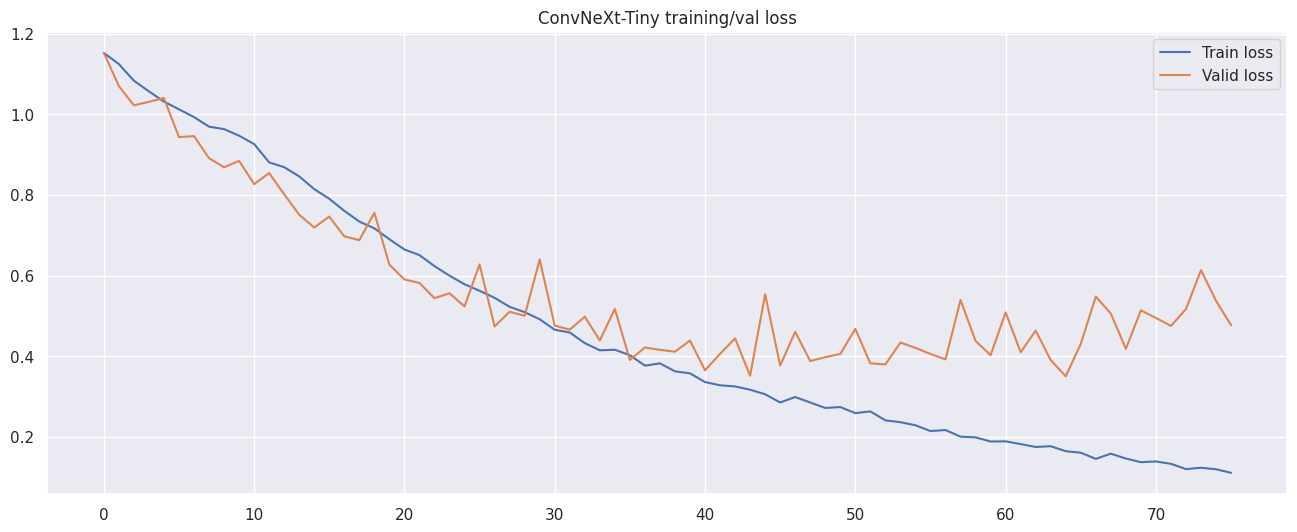

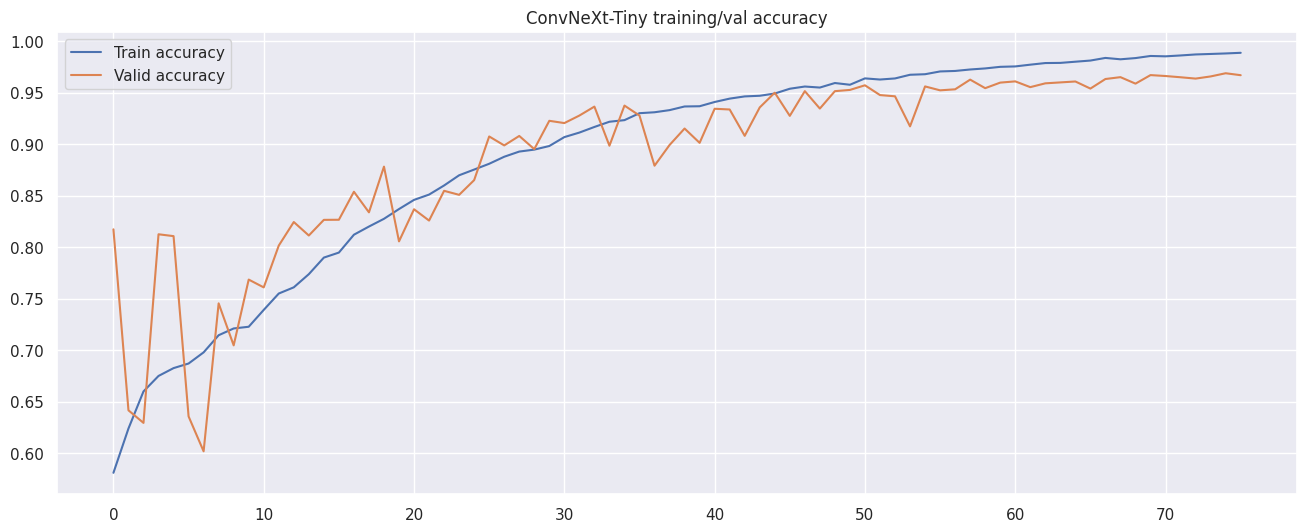

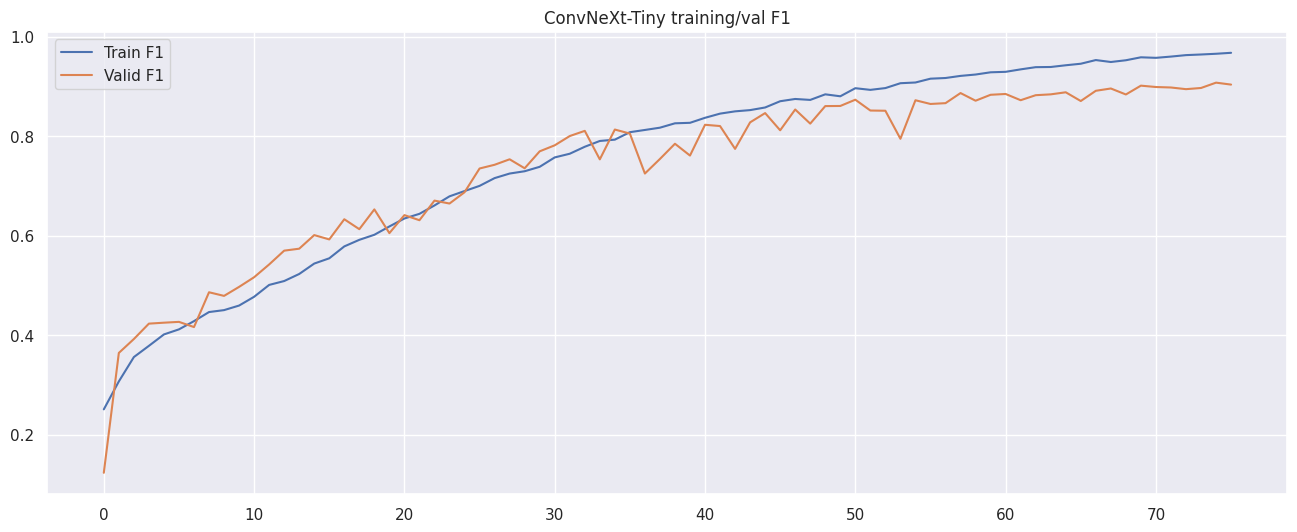

Epoch 76/100
Train loss: 0.1105 | Val loss: 0.4768
Train acc:  0.9889 | Val acc:  0.9671
Train F1:   0.9673 | Val F1:   0.9034
Best Val F1 so far: 0.9074


  0%|          | 0/1250 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
fit(
    model,
    train_loader,
    val_loader,
    test_loader,
    optimizer,
    criterion,
    scheduler,
    num_epochs,
    title="ConvNeXt-Tiny training/val"
)

# Дообучение

In [ ]:
train_transforms_phase2 = A.Compose([
    A.RandomResizedCrop(224, 224, scale=(0.9, 1.0), p=1.0),

    A.HorizontalFlip(p=0.5),

    A.ShiftScaleRotate(
        shift_limit=0.02,
        scale_limit=0.05,
        rotate_limit=3,
        p=0.2
    ),
    A.OneOf([
        A.MedianBlur(blur_limit=3, p=1.0),
        A.ImageCompression(quality_lower=85, quality_upper=100, p=1.0),
    ], p=0.1),

    A.RandomBrightnessContrast(brightness_limit=0.1, contrast_limit=0.1, p=0.2),
    A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=15, val_shift_limit=10, p=0.1),

    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

val_transforms_convnext = A.Compose([
    A.Resize(224, 224, p=1.0),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

train_dataset_phase2 = TrainDataset(train_df, "/content/train_images", transform=train_transforms_phase2)
val_dataset_phase2   = TrainDataset(val_df,   "/content/train_images", transform=val_transforms_convnext)

train_loader_phase2 = DataLoader(train_dataset_phase2, batch_size=32, shuffle=True, num_workers=4, pin_memory=True, persistent_workers=True, prefetch_factor=2)
val_loader_phase2   = DataLoader(val_dataset_phase2, batch_size=32, shuffle=False, num_workers=4, pin_memory=True, persistent_workers=True, prefetch_factor=2)

from copy import deepcopy

model_ConvNeXt_Tiny_epoch_64 = convnext_tiny_ultimate().to(device)
model_ConvNeXt_Tiny_epoch_64.load_state_dict(
    torch.load("/content/drive/MyDrive/YAN/64_0.8838.pth", map_location=device)
)

ema_model = deepcopy(model_ConvNeXt_Tiny_epoch_64).to(device)
ema_model.eval()

def update_ema(model, ema_model, decay=0.999):
    with torch.no_grad():
        for ema_param, param in zip(ema_model.parameters(), model.parameters()):
            ema_param.data.mul_(decay).add_(param.data, alpha=1 - decay)

In [ ]:
def train(model: nn.Module, data_loader: DataLoader, optimizer, loss_fn, threshold=0.5, ema_model=None):
    model.train()

    total_loss = 0.0
    all_preds = []
    all_true = []

    for x, y in tqdm(data_loader):
        x = x.to(device)
        y = y.float().to(device)

        optimizer.zero_grad()

        output = model(x).view(-1)
        loss = loss_fn(output, y)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        if ema_model is not None:
            update_ema(model, ema_model)

        probs = torch.sigmoid(output)
        preds = (probs >= threshold).long()

        total_loss += loss.item()
        all_preds.extend(preds.detach().cpu().numpy())
        all_true.extend(y.long().detach().cpu().numpy())

    acc = accuracy_score(all_true, all_preds)
    prec = precision_score(all_true, all_preds, average='binary', zero_division=0)
    rec = recall_score(all_true, all_preds, average='binary', zero_division=0)
    f1 = f1_score(all_true, all_preds, average='binary', zero_division=0)

    return total_loss / len(data_loader), acc, prec, rec, f1

    @torch.inference_mode()
def evaluate(model: nn.Module, data_loader: DataLoader, loss_fn, threshold=0.5):
    model.eval()

    total_loss = 0.0
    all_preds = []
    all_true = []

    for x, y in tqdm(data_loader):
        x = x.to(device)
        y = y.float().to(device)

        output = model(x).view(-1)
        loss = loss_fn(output, y)

        probs = torch.sigmoid(output)
        preds = (probs >= threshold).long()

        total_loss += loss.item()
        all_preds.extend(preds.cpu().numpy())
        all_true.extend(y.long().cpu().numpy())

    acc = accuracy_score(all_true, all_preds)
    prec = precision_score(all_true, all_preds, average='binary', zero_division=0)
    rec = recall_score(all_true, all_preds, average='binary', zero_division=0)
    f1 = f1_score(all_true, all_preds, average='binary', zero_division=0)

    return total_loss / len(data_loader), acc, prec, rec, f1


from IPython.display import clear_output
import os
import torch


from IPython.display import clear_output
import os
import torch

def fit(model, ema_model, train_loader, valid_loader, optimizer, loss_fn, scheduler, num_epochs, title):
    train_loss_history, valid_loss_history = [], []
    train_accuracy_history, valid_accuracy_history = [], []
    train_f1_history, valid_f1_history = [], []

    best_valid_f1 = float('-inf')

    save_dir = "/content/drive/MyDrive/YAN"
    os.makedirs(save_dir, exist_ok=True)

    for epoch in range(num_epochs):
        train_loss, train_accuracy, train_prec, train_rec, train_f1 = train(
            model, train_loader, optimizer, loss_fn, ema_model=ema_model
        )

        valid_loss, valid_accuracy, valid_prec, valid_rec, valid_f1 = evaluate(
            ema_model, valid_loader, loss_fn
        )

        scheduler.step(valid_f1)

        train_loss_history.append(train_loss)
        valid_loss_history.append(valid_loss)
        train_accuracy_history.append(train_accuracy)
        valid_accuracy_history.append(valid_accuracy)
        train_f1_history.append(train_f1)
        valid_f1_history.append(valid_f1)

        save_path = os.path.join(save_dir, f"{epoch+1}_f1_{valid_f1:.4f}_val_{valid_loss:.4f}.pth")
        torch.save(ema_model.state_dict(), save_path)

        if valid_f1 > best_valid_f1:
            best_valid_f1 = valid_f1

        clear_output()
        plot_stats(
            train_loss_history, valid_loss_history,
            train_accuracy_history, valid_accuracy_history,
            train_f1_history, valid_f1_history,
            title
        )

        print(f"Epoch {epoch+1}/{num_epochs}")
        print(f"Train loss: {train_loss:.4f} | Val loss: {valid_loss:.4f}")
        print(f"Train acc:  {train_accuracy:.4f} | Val acc:  {valid_accuracy:.4f}")
        print(f"Train F1:   {train_f1:.4f} | Val F1:   {valid_f1:.4f}")
        print(f"Best Val F1 so far: {best_valid_f1:.4f}")






num_epochs = 15

n_pos = train_df["label"].sum()
n_neg = len(train_df) - n_pos
pos_weight = torch.tensor([n_neg / n_pos], device=device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.AdamW(
    model_ConvNeXt_Tiny_epoch_64.parameters(),
    lr=1e-5,
    weight_decay=5e-3
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=2,
    min_lr=1e-6
)


# EMA

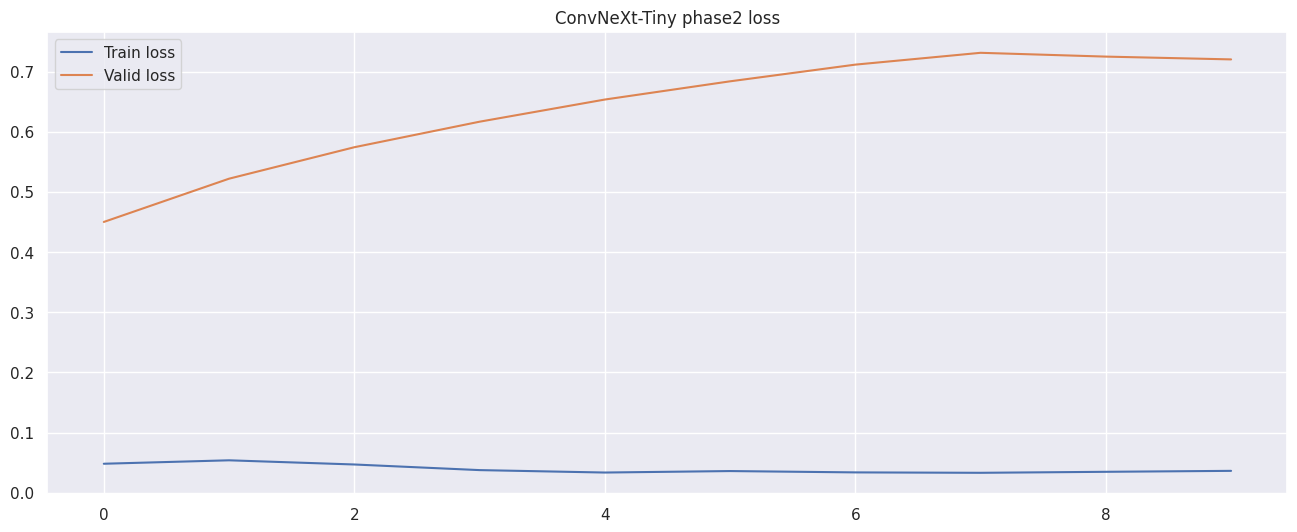

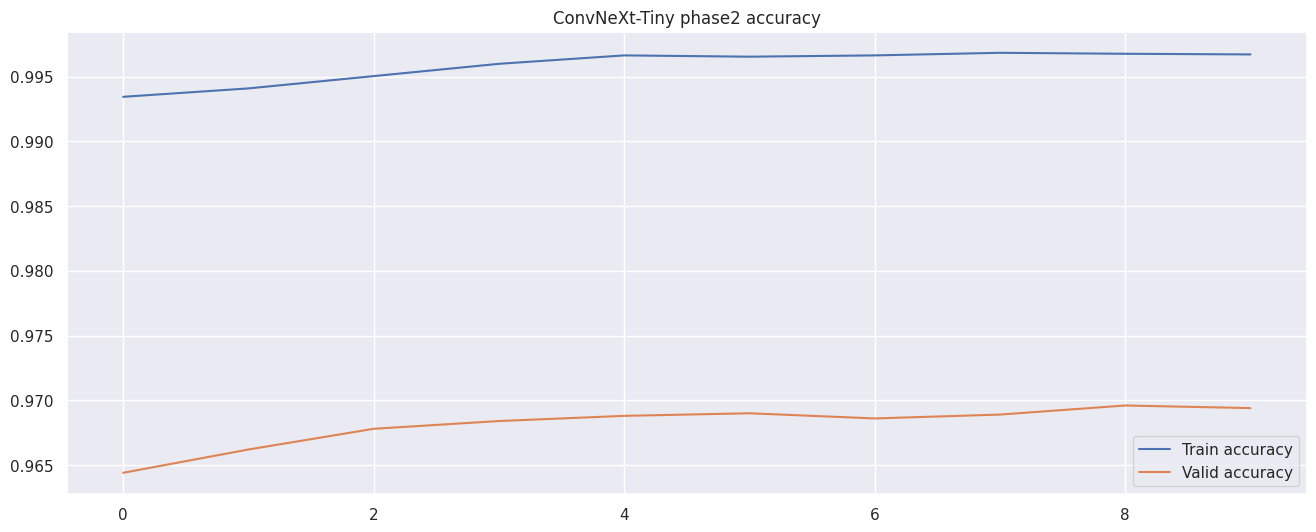

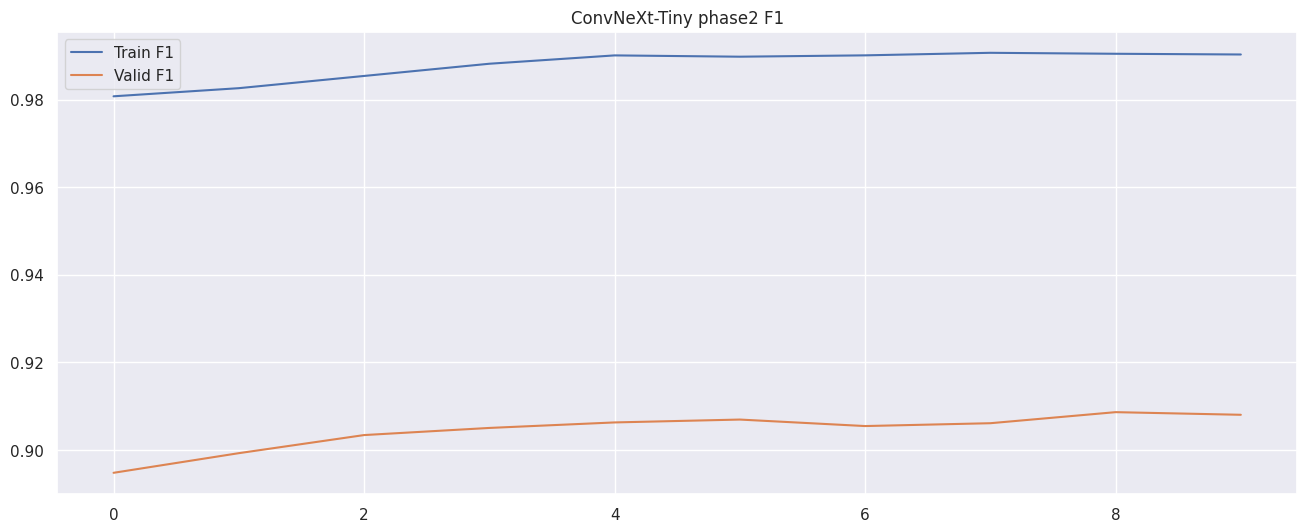

Epoch 10/15
Train loss: 0.0365 | Val loss: 0.7202
Train acc:  0.9967 | Val acc:  0.9694
Train F1:   0.9904 | Val F1:   0.9081
Best Val F1 so far: 0.9087


  0%|          | 0/1250 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
fit(
    model_ConvNeXt_Tiny_epoch_64,
    ema_model,
    train_loader_phase2,
    val_loader_phase2,
    optimizer,
    criterion,
    scheduler,
    num_epochs,
    title="ConvNeXt-Tiny phase2"
)